In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# 1. Load all 4 files
p_real = pd.read_csv('politifact_real.csv')
p_fake = pd.read_csv('politifact_fake.csv')
g_real = pd.read_csv('gossipcop_real.csv')
g_fake = pd.read_csv('gossipcop_fake.csv')

# 2. Assign labels (0 = Real, 1 = Fake)
p_real['label'], g_real['label'] = 0, 0
p_fake['label'], g_fake['label'] = 1, 1

# 3. Combine into one dataframe
df = pd.concat([p_real, p_fake, g_real, g_fake]).reset_index(drop=True)

# 4. We use the 'title' column as our input text
X = df['title'].astype(str)
y = df['label']

# 5. Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Global dictionary to store accuracies
final_accuracies = {}

# Performance Visualization Helper
def plot_metrics(y_true, y_probs, name):
    y_pred = (y_probs > 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    final_accuracies[name] = acc

    print(f"\n--- {name} Results ---")
    print(f"Accuracy: {acc*100:.2f}%")

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='YlGnBu', ax=ax[0])
    ax[0].set_title(f"Confusion Matrix: {name}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    ax[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
    ax[1].plot([0,1],[0,1], '--')
    ax[1].set_title(f"ROC Curve: {name}")
    plt.legend()
    plt.show()


--- Naive Bayes Results ---
Accuracy: 83.64%


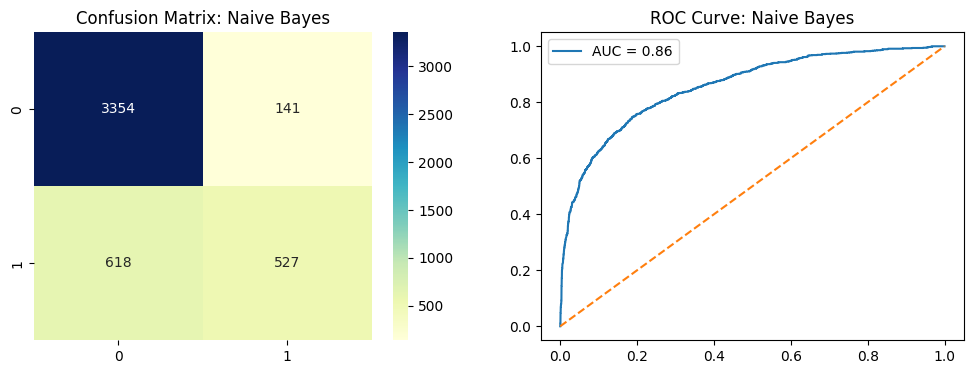


--- SVM Results ---
Accuracy: 83.81%


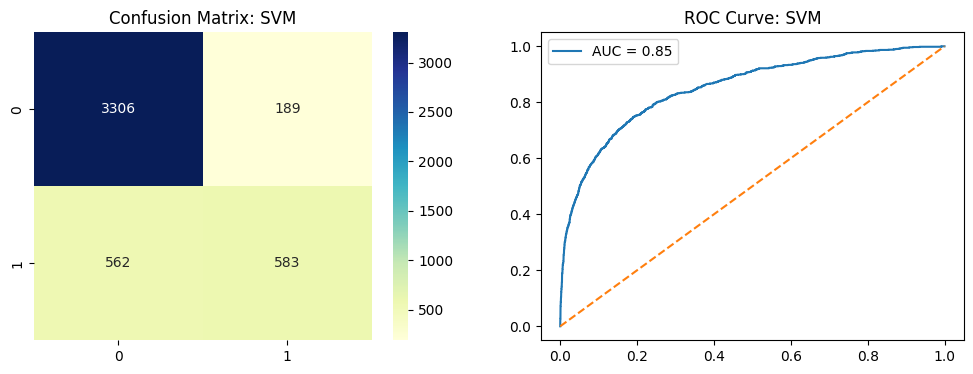

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Vectorize titles
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 1. Naive Bayes
nb = MultinomialNB().fit(X_train_vec, y_train)
plot_metrics(y_test, nb.predict_proba(X_test_vec)[:, 1], "Naive Bayes")

# 2. SVM (Calibrated for ROC probabilities)
svm = CalibratedClassifierCV(LinearSVC()).fit(X_train_vec, y_train)
plot_metrics(y_test, svm.predict_proba(X_test_vec)[:, 1], "SVM")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8013 - loss: 0.4476
Epoch 2/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8786 - loss: 0.2955
Epoch 3/3
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9067 - loss: 0.2245
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- LSTM Results ---
Accuracy: 83.62%


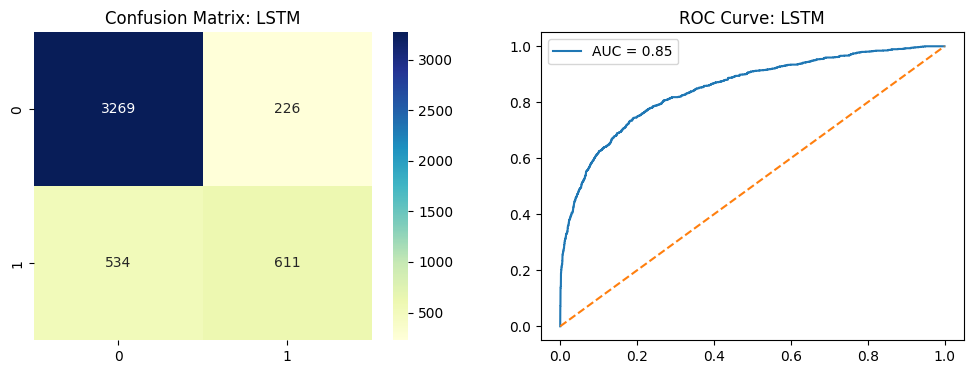

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

# Tokenize
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=50)
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=50)

# Build LSTM
lstm = Sequential([
    Embedding(10000, 64, input_length=50),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm.fit(X_train_pad, y_train, epochs=3, batch_size=32, verbose=1)

plot_metrics(y_test, lstm.predict(X_test_pad).flatten(), "LSTM")

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import tensorflow as tf

def train_transformer(model_path, name):
    print(f"\nTraining {name} on titles...")
    tokenizer = AutoTokenizer.from_pretrained(model_path)

    # Prep data
    train_enc = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=64, return_tensors="tf")
    test_enc = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=64, return_tensors="tf")

    model = TFAutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
    model.compile(optimizer=tf.keras.optimizers.Adam(2e-5), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

    # Train for 1 epoch for speed (increase if needed)
    model.fit(dict(train_enc), np.array(y_train), epochs=1, batch_size=16)

    # Predict and Evaluate
    logits = model.predict(dict(test_enc)).logits
    probs = tf.nn.softmax(logits, axis=1).numpy()[:, 1]
    plot_metrics(y_test, probs, name)

# 4. RoBERTa
train_transformer("roberta-base", "RoBERTa")

# 5. ALBERT
train_transformer("albert-base-v2", "ALBERT")

ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (/usr/local/lib/python3.12/dist-packages/transformers/__init__.py)

In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_transformer(model_path, name):
    print(f"\nTraining {name} on titles...")

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    train_enc = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=64, return_tensors="pt")
    test_enc = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=64, return_tensors="pt")

    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    model.train()

    for epoch in range(1):
        for i in range(0, len(X_train), 16):
            batch_input = {k: v[i:i+16].to(device) for k, v in train_enc.items()}
            batch_labels = torch.tensor(y_train[i:i+16].values, dtype=torch.long).to(device)

            outputs = model(**batch_input, labels=batch_labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

    # Evaluation
    model.eval()
    with torch.no_grad():
        test_enc = {k: v.to(device) for k, v in test_enc.items()}
        outputs = model(**test_enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[:, 1]

    plot_metrics(y_test, probs, name)


Training RoBERTa on titles...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- RoBERTa Results ---
Accuracy: 86.72%


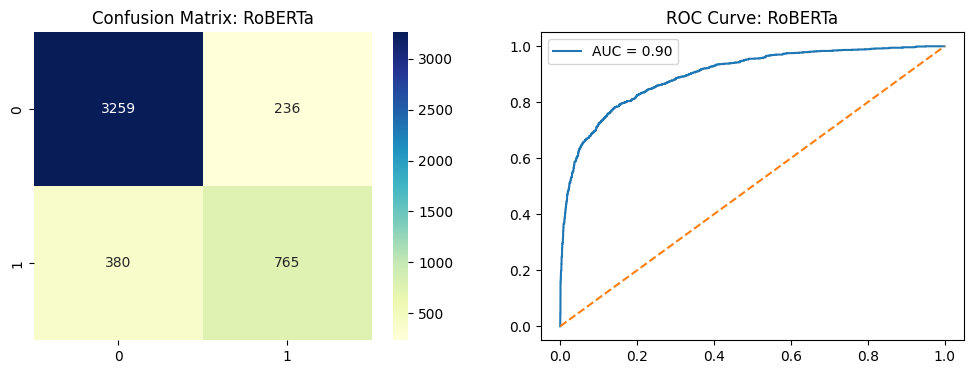


Training ALBERT on titles...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.81 GiB. GPU 0 has a total capacity of 14.56 GiB of which 1.55 GiB is free. Including non-PyTorch memory, this process has 13.01 GiB memory in use. Of the allocated memory 8.72 GiB is allocated by PyTorch, and 4.16 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
train_transformer("roberta-base", "RoBERTa")
train_transformer("albert-base-v2", "ALBERT")

In [ ]:
train_transformer("albert-base-v2", "ALBERT")


Training ALBERT on titles...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.81 GiB. GPU 0 has a total capacity of 14.56 GiB of which 2.81 GiB is free. Including non-PyTorch memory, this process has 11.75 GiB memory in use. Of the allocated memory 10.14 GiB is allocated by PyTorch, and 1.48 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def train_transformer(model_path, name):
    print(f"\n🚀 Training {name}...")

    # 🔥 MEMORY SAFE SETTINGS
    BATCH_SIZE = 2          # VERY IMPORTANT
    MAX_LEN = 32            # keep small
    ACCUM_STEPS = 8         # simulate batch=16
    EPOCHS = 2              # reduce slightly

    tokenizer = AutoTokenizer.from_pretrained(model_path)

    # 🔥 Convert labels early
    y_train_np = y_train.values
    y_test_np = y_test.values

    # 🔥 Class weights (important but light)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_np),
        y=y_train_np
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

    scaler = torch.amp.GradScaler("cuda")

    model.train()

    # 🔥 TRAINING LOOP (TOKENIZE PER BATCH → saves memory)
    for epoch in range(EPOCHS):
        optimizer.zero_grad()

        for step, i in enumerate(range(0, len(X_train), BATCH_SIZE)):

            batch_text = X_train.iloc[i:i+BATCH_SIZE].tolist()

            batch_enc = tokenizer(
                batch_text,
                truncation=True,
                padding=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            )

            batch_input = {k: v.to(device) for k, v in batch_enc.items()}

            batch_labels = torch.tensor(
                y_train_np[i:i+BATCH_SIZE],
                dtype=torch.long
            ).to(device)

            with torch.amp.autocast("cuda"):
                outputs = model(**batch_input)
                logits = outputs.logits
                loss = loss_fn(logits, batch_labels) / ACCUM_STEPS

            scaler.scale(loss).backward()

            if (step + 1) % ACCUM_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

        print(f"✅ Epoch {epoch+1} done")

    # 🔥 EVALUATION (BATCHED → NO OOM)
    model.eval()

    all_probs = []

    with torch.no_grad():
        for i in range(0, len(X_test), BATCH_SIZE):
            batch_text = X_test.iloc[i:i+BATCH_SIZE].tolist()

            batch_enc = tokenizer(
                batch_text,
                truncation=True,
                padding=True,
                max_length=MAX_LEN,
                return_tensors="pt"
            )

            batch_input = {k: v.to(device) for k, v in batch_enc.items()}

            outputs = model(**batch_input)
            logits = outputs.logits

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)

    probs = np.array(all_probs)

    # 🔥 BETTER THRESHOLD
    preds = (probs > 0.4).astype(int)

    accuracy = (preds == y_test_np).mean()
    print(f"\n🎯 {name} Accuracy: {accuracy:.4f}")

    plot_metrics(y_test_np, probs, name)

    # 🔥 CLEAN MEMORY
    del model
    torch.cuda.empty_cache()



🚀 Training ALBERT...


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.bias       | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Epoch 1 done
✅ Epoch 2 done

🎯 ALBERT Accuracy: 0.7944

--- ALBERT Results ---
Accuracy: 81.96%


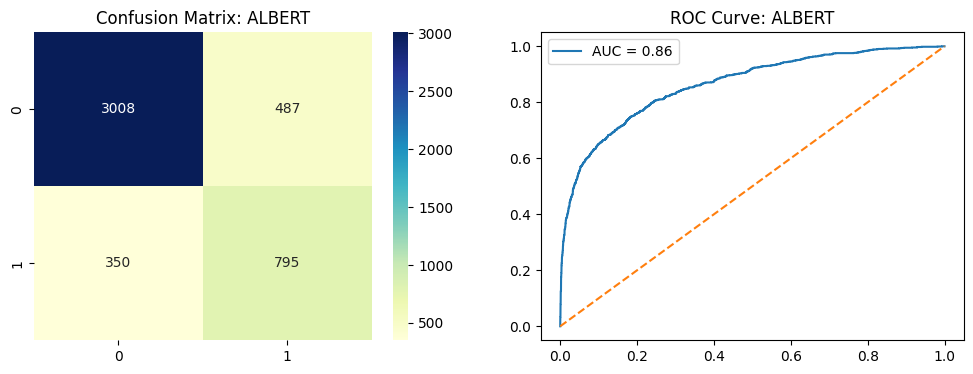

In [5]:
train_transformer("albert-base-v2", "ALBERT")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.7504 - loss: 0.5603
Epoch 2/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.7515 - loss: 0.5527
Epoch 3/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7517 - loss: 0.5481
Epoch 4/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7515 - loss: 0.5457
Epoch 5/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7520 - loss: 0.5390
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- LSTM with Word2Vec Accuracy: 75.32% ---


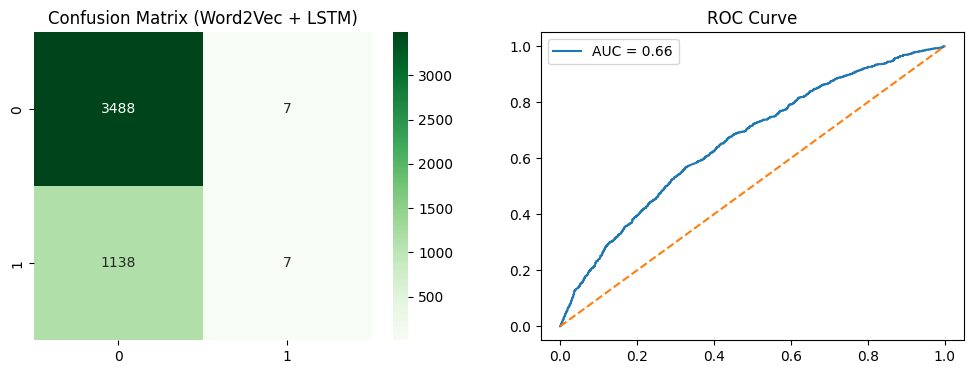

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

# 1. Load and Merge Data
p_real = pd.read_csv('politifact_real.csv')
p_fake = pd.read_csv('politifact_fake.csv')
g_real = pd.read_csv('gossipcop_real.csv')
g_fake = pd.read_csv('gossipcop_fake.csv')

p_real['label'], g_real['label'] = 0, 0
p_fake['label'], g_fake['label'] = 1, 1

df = pd.concat([p_real, p_fake, g_real, g_fake]).reset_index(drop=True)
X = df['title'].astype(str)
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Word2Vec Model
# We split the text into lists of words for Gensim
sentences = [sentence.split() for sentence in X_train_text]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

# 3. Tokenize for Keras
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_text)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=50)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=50)

vocab_size = len(tokenizer.word_index) + 1

# 4. Create Embedding Matrix
# We map the Word2Vec vectors to our Tokenizer's word indices
embedding_matrix = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

# 5. Build LSTM with Pre-trained Embeddings
model = Sequential([
    # We load the embedding_matrix into the weights and set trainable=False
    # so the model uses the Word2Vec logic
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=50, trainable=False),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_seq, y_train, epochs=5, batch_size=32)

# 6. Performance Evaluation
y_probs = model.predict(X_test_seq).flatten()
y_pred = (y_probs > 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\n--- LSTM with Word2Vec Accuracy: {acc*100:.2f}% ---")

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title("Confusion Matrix (Word2Vec + LSTM)")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
ax[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
ax[1].plot([0,1],[0,1], '--')
ax[1].set_title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# 1. Install/Update Gensim and ensure it's available
!pip install -q -U gensim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# Import Gensim for Word2Vec
from gensim.models import Word2Vec

# TensorFlow imports
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

print("All modules imported successfully!")

# --- Rest of your code follows ---
# (Loading data, training Word2Vec, and building the LSTM)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 50.5 MB/s eta 0:00:00
All modules imported successfully!


In [ ]:
# Download the 100-dimensional GloVe vectors
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-03-29 15:35:45--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-29 15:35:45--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-29 15:35:45--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


580/580 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7817 - loss: 0.4821
Epoch 2/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8134 - loss: 0.4254
Epoch 3/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8286 - loss: 0.3994
Epoch 4/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8397 - loss: 0.3780
Epoch 5/5
580/580 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8499 - loss: 0.3538
145/145 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- GloVe + LSTM Accuracy: 83.15% ---


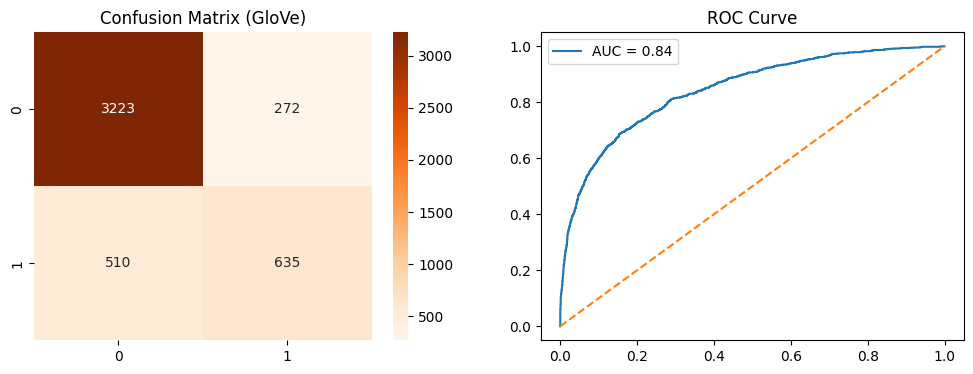

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout

# 1. Load and Prep Data
p_real, p_fake = pd.read_csv('politifact_real.csv'), pd.read_csv('politifact_fake.csv')
g_real, g_fake = pd.read_csv('gossipcop_real.csv'), pd.read_csv('gossipcop_fake.csv')
p_real['label'], g_real['label'], p_fake['label'], g_fake['label'] = 0, 0, 1, 1

df = pd.concat([p_real, p_fake, g_real, g_fake]).reset_index(drop=True)
X_train, X_test, y_train, y_test = train_test_split(df['title'].astype(str), df['label'], test_size=0.2, random_state=42)

# 2. Tokenization
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=50)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=50)

# 3. Load GloVe into a Dictionary
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

# 4. Create Embedding Matrix
vocab_size = len(tokenizer.word_index) + 1
embedding_matrix = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# 5. Build LSTM with GloVe
model = Sequential([
    # Weights are initialized with the GloVe matrix
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=50, trainable=False),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_seq, y_train, epochs=5, batch_size=32)

# 6. Evaluation
y_probs = model.predict(X_test_seq).flatten()
y_pred = (y_probs > 0.5).astype(int)

print(f"\n--- GloVe + LSTM Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}% ---")

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title("Confusion Matrix (GloVe)")

fpr, tpr, _ = roc_curve(y_test, y_probs)
ax[1].plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
ax[1].plot([0,1],[0,1], '--')
ax[1].set_title("ROC Curve")
plt.legend()
plt.show()